G:\Anaconda3\Anaconda\envs\python2.9\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Asignación de clusters en TEST (primeras filas):
    cliente      importe  n_productos  cluster
19     C020   197.004445     2.690653        1
42     C043   160.069418     2.643736        1
153    C154  1976.770296    11.972565        2
78     C079  1039.607707     7.992317        0
145    C146  1782.288847    15.461549        2
15     C016   148.442452     3.690485        1
24     C025   174.300331     1.804160        1
68     C069   723.229816     5.947761        0
113    C114   652.927308     9.808780        0
118    C119   785.763401     6.406378        0

Clientes nuevos -> cluster asignado:
importe=350€, n_productos=4  =>  cluster 1
importe=900€, n_productos=9  =>  cluster 0
importe=1900€, n_productos=16  =>  cluster 2


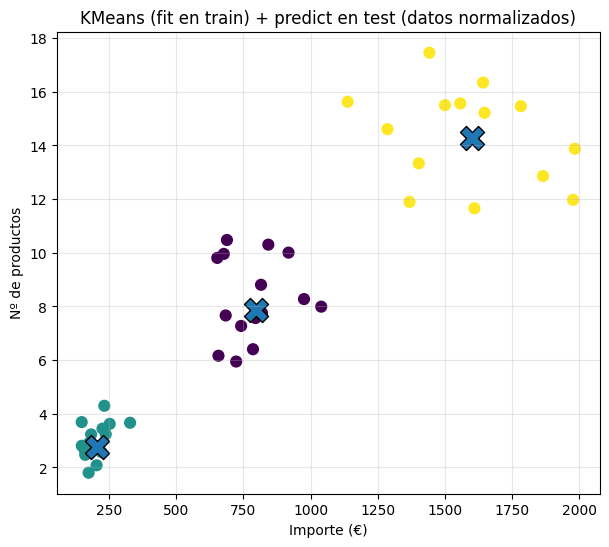

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ----------------------------
# 1) Dataset de ejemplo (clientes)
#    features: importe (€) y n_productos
# ----------------------------
rng = np.random.default_rng(42)

def make_group(n, imp_mu, imp_sd, prod_mu, prod_sd):
    imp = rng.normal(imp_mu, imp_sd, n)
    prod = rng.normal(prod_mu, prod_sd, n)
    return np.column_stack([imp, prod])

X = np.vstack([
    make_group(60,  200,  60,  3, 1.0),   # bajo
    make_group(60,  800, 120,  8, 1.5),   # medio
    make_group(60, 1600, 180, 14, 2.0)    # alto
])

# Limpiar mínimos
X[:, 0] = np.clip(X[:, 0], 50, None)  # importe >= 50
X[:, 1] = np.clip(X[:, 1], 1, None)   # n_productos >= 1

df = pd.DataFrame(X, columns=["importe", "n_productos"])
df.insert(0, "cliente", [f"C{str(i+1).zfill(3)}" for i in range(len(df))])

# ----------------------------
# 2) Train / Test split (solo para demostrar "fit en train" y "predict en test")
# ----------------------------
X_train, X_test, df_train, df_test = train_test_split(
    X, df[["cliente", "importe", "n_productos"]],
    test_size=0.25, random_state=42
)

# ----------------------------
# 3) Pipeline: Normalización + KMeans
# ----------------------------
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42, n_init="auto"))
])

# "Train" (fit) con train
pipe.fit(X_train)

# "Predict" (asignar cluster) en test
test_clusters = pipe.predict(X_test)

df_test = df_test.copy()
df_test["cluster"] = test_clusters

print("Asignación de clusters en TEST (primeras filas):")
print(df_test.head(10))

# ----------------------------
# 4) Ejemplo de predicción para "clientes nuevos"
# ----------------------------
nuevos = np.array([
    [350, 4],     # cliente con importe bajo-medio y pocos productos
    [900, 9],     # medio
    [1900, 16],   # alto
])

clusters_nuevos = pipe.predict(nuevos)

print("\nClientes nuevos -> cluster asignado:")
for x, c in zip(nuevos, clusters_nuevos):
    print(f"importe={x[0]:.0f}€, n_productos={x[1]:.0f}  =>  cluster {c}")

# ----------------------------
# 5) Plot rápido (opcional) para ver TEST + centroides (en escala original)
# ----------------------------
# centroides están en el espacio normalizado; los devolvemos a escala original
centroids_scaled = pipe.named_steps["kmeans"].cluster_centers_
centroids = pipe.named_steps["scaler"].inverse_transform(centroids_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_clusters, s=60)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, marker="X", edgecolors="k")
plt.title("KMeans (fit en train) + predict en test (datos normalizados)")
plt.xlabel("Importe (€)")
plt.ylabel("Nº de productos")
plt.grid(True, alpha=0.3)
plt.show()
